# Univariate Data Analysis
In this notebook, we analyze the features individually to understand their shapes, structures, and overall distributions using visualization techniques.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme(style='darkgrid')

In [3]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# Data Analysis: tip
Analyzing the distribution of our target variable, `tip`. We use a histogram to observe the frequency distribution and a box plot to identify quartiles and potential outliers.

<Axes: ylabel='tip'>

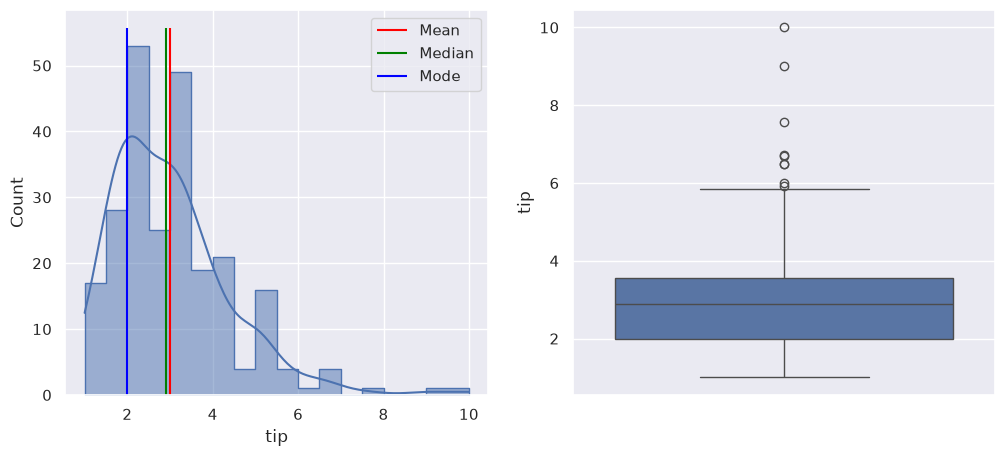

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='tip', element='step', kde=True, ax=ax1)
ylim = ax1.get_ylim()[1]
ax1.vlines(x=df['tip'].mean(), ymin=0, ymax=ylim, color='red', label='Mean')
ax1.vlines(x=df['tip'].median(), ymin=0, ymax=ylim, color='green', label='Median')
ax1.vlines(x=df['tip'].mode(), ymin=0, ymax=ylim, color='blue', label='Mode')

ax1.legend()

sns.boxplot(data=df, y='tip', ax=ax2)

**Observations:**
- As shown in the histogram, the distribution of the `tip` amount is **positively skewed** (right-skewed), meaning most tips are on the lower end, with a few unusually high tips stretching the tail to the right.
- The box plot highlights the presence of **outliers** on the upper end.
- Additionally, we can observe that as the tip amount increases, the variance (spread) of the data also appears to increase.

# Data Analysis: total_bill
Analyzing the distribution of the `total_bill` feature using a histogram and a box plot.

<Axes: ylabel='total_bill'>

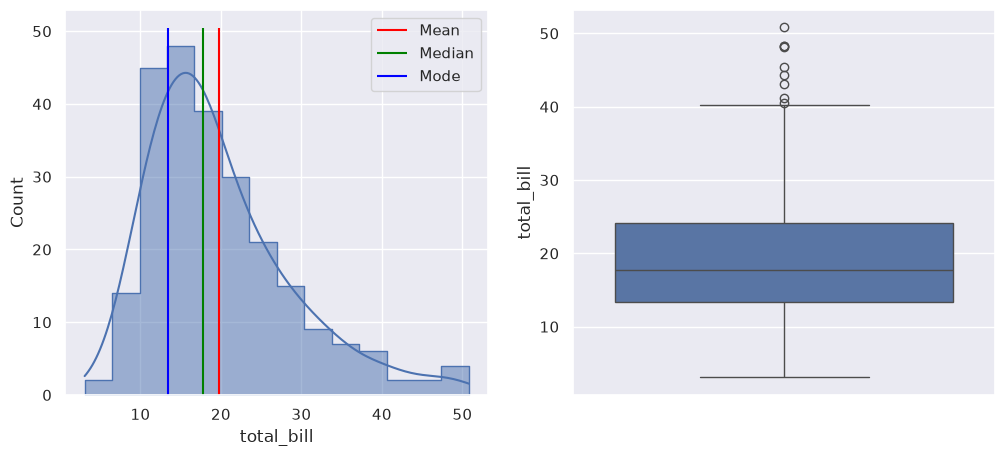

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='total_bill', kde=True, element='step', ax=ax1)
ylim = ax1.get_ylim()[1]
ax1.vlines(x=df['total_bill'].mean(), ymin=0, ymax=ylim, colors='red', label='Mean')
ax1.vlines(x=df['total_bill'].median(), ymin=0, ymax=ylim, colors='green', label='Median')
ax1.vlines(x=df['total_bill'].mode(), ymin=0, ymax=ylim, colors='blue', label='Mode')

ax1.legend()

sns.boxplot(data=df, y='total_bill', ax=ax2)

**Observations:**
- Similar to the target variable, the histogram for `total_bill` shows a **positively skewed** distribution.
- The box plot reveals several **outliers** on the higher end of the bill amounts.
- Overall, `total_bill` exhibits a very similar distribution behavior to the `tip` variable, which suggests a strong potential correlation between the two.

# Data Analysis: Categorical Features (sex, smoker, day, time)
Analyzing the categorical features in our dataset by visualizing their frequency counts using count plots.

<Axes: xlabel='time', ylabel='count'>

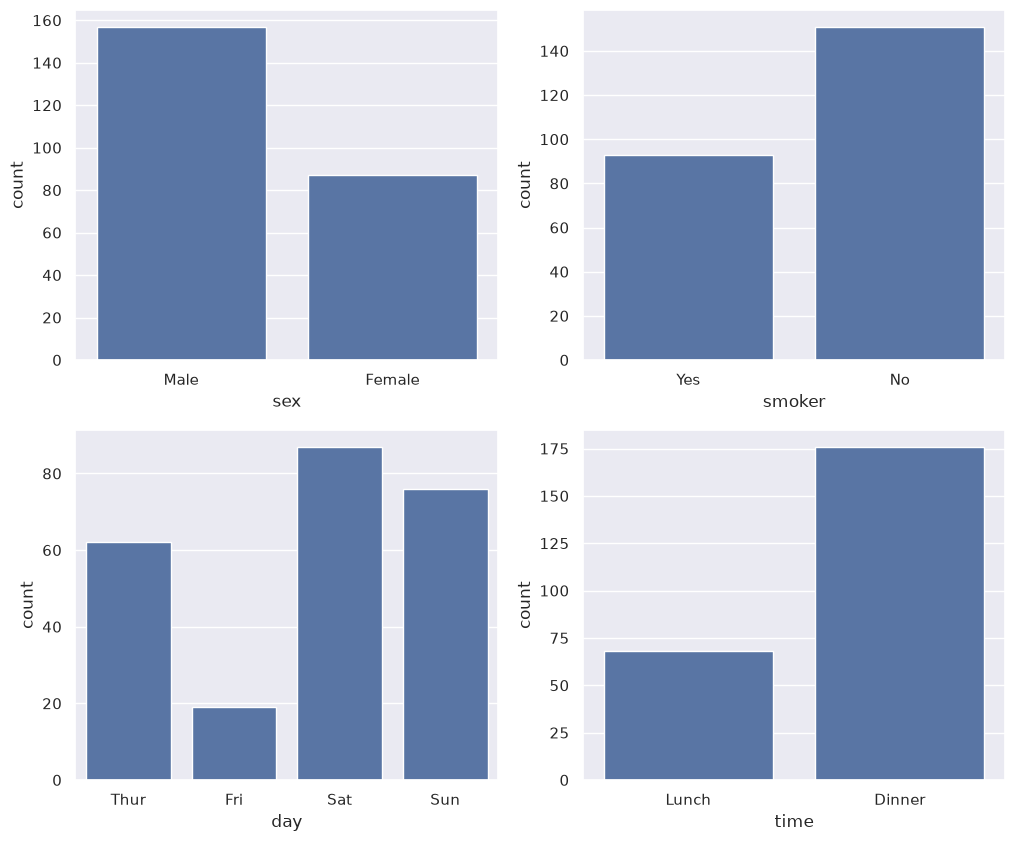

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x='sex', ax=ax1)
sns.countplot(data=df, x='smoker', ax=ax2)
sns.countplot(data=df, x='day', ax=ax3)
sns.countplot(data=df, x='time', ax=ax4)

**Observations:**
- **sex**: Male > Female
- **smoker**: Non-smoker > Smoker
- **day**: Saturday > Sunday > Thursday > Friday
- **time**: Dinner > Lunch

There are significant imbalances in the category counts. For example, the number of records for females is almost half that of males. Similar imbalances exist across the other categorical features. These imbalances are important to note because they can influence the model's ability to generalize across different groups.

# Data Analysis: size
Analyzing the `size` feature (number of people in a party) using a count plot. Although its data type is integer, it takes on a small, discrete set of values (1 through 6) and can effectively be analyzed as a categorical variable.

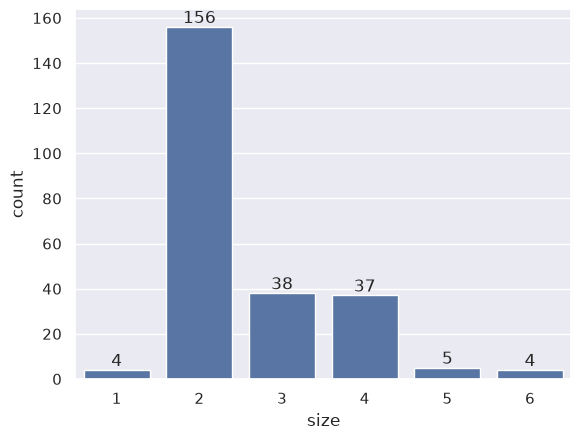

In [ ]:
ax1 = sns.countplot(data=df, x='size')

ax1.bar_label(ax1.containers[0]); # Automatically labels the bars with their respective counts

**Observations:**
- The distribution of data across different party sizes is heavily skewed. Most of the data represents parties of `size=2`.
- There are very few records for solo diners (`size=1`) and larger groups (`size=5`, `size=6`).
- **Impact on Modeling**: This severe imbalance means our final model will have less data to learn from regarding solo diners and larger tables. Consequently, it may be weaker at predicting tip amounts for those specific party sizes, which is particularly notable since larger tables naturally tend to have higher total bills.